In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [119]:
n = 100
m = 100
p = 2
d = 1
sigma2 = 1e-3
tau = 1e-1

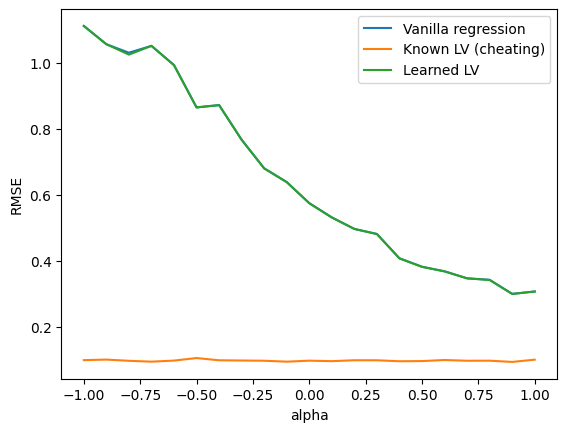

In [120]:
alpha = np.arange(-1, 1.1, 0.1)
A = len(alpha)
T = 20
RMSE_background = np.zeros((A,T))
RMSE_latent = np.zeros((A,T))
RMSE_pca = np.zeros((A,T))

for i in range(A):
    
    S = np.array([[1, 1]]).T
    W = S + alpha[i] * np.array([[1, 1]]).T
    beta = np.ones((d, 1))
    
    
    for j in range(T):
        
        # latent variables 
        z_a = np.random.normal(size=(n, 1))
        z_b = np.random.normal(size=(m, 1))
        t = np.random.normal(size=(n, 1))
        
        # noise in LVM
        epsilon_a = np.random.normal(size=(n, 1), scale=np.sqrt(sigma2))
        epsilon_b = np.random.normal(size=(m, 1), scale=np.sqrt(sigma2))
        
        # noise in linear regression
        eta = np.random.normal(size=(n, 1), scale=np.sqrt(tau))
        
     
        X = z_a @ S.T + t * W.T + epsilon_a
        Y = z_b @ S.T + epsilon_b
        r = t @ beta.T + eta
        
        
        data = np.hstack([X, r])
        
        gamma = 10
        cSigma = 1 / n * X.T @ X - gamma * 1 / m * Y.T @ Y
        
        [V,D,P] = np.linalg.svd(cSigma);
        X_bk = X @ V[:, :d]
        data_red = np.hstack([X_bk, r])
        data_true = np.hstack([t, r])
        
        
        mdl_back = LinearRegression().fit(X, r)
        mdl_latent = LinearRegression().fit(t, r)
        mdl_pca = LinearRegression().fit(X_bk, r)
        
        
#         RMSE_background[i, j] = mdl_back.score(X, r)
#         RMSE_latent[i, j] = mdl_latent.score(t, r)
#         RMSE_pca[i, j] = mdl_pca.score(X_bk, r)
        RMSE_background[i, j] = mean_squared_error(mdl_back.predict(X), r)
        RMSE_latent[i, j] = mean_squared_error(mdl_latent.predict(t), r)
        RMSE_pca[i, j] = mean_squared_error(mdl_pca.predict(X_bk), r)


# figure
plt.plot(alpha, np.mean(RMSE_background,1), label="Vanilla regression")
plt.plot(alpha, np.mean(RMSE_latent, 1), label="Known LV (cheating)")
plt.plot(alpha, np.mean(RMSE_pca, 1), label="Learned LV")

plt.xlabel('alpha')
plt.ylabel('RMSE')
plt.legend()
plt.show()

In [113]:
alpha = 1
n = 100
m = 100
p = 2
d = 1
sigma2 = 1e-3
tau = 1e-1

    
S = np.array([[1, 1]]).T
W = S + alpha * np.array([[1, 1]]).T
beta = np.ones((d, 1))
            
# latent variables 
z_a = np.random.normal(size=(n, 1))
z_b = np.random.normal(size=(m, 1))
t = np.random.normal(size=(n, 1))

# noise in LVM
epsilon_a = np.random.normal(size=(n, 1), scale=np.sqrt(sigma2))
epsilon_b = np.random.normal(size=(m, 1), scale=np.sqrt(sigma2))

# noise in linear regression
eta = np.random.normal(size=(n, 1), scale=np.sqrt(tau))


X = z_a @ S.T + t * W.T + epsilon_a
Y = z_b @ S.T + epsilon_b
r = t @ beta + eta


data = np.hstack([X, r])

gamma = 10
cSigma = 1 / n * X.T @ X - gamma * 1 / m * Y.T @ Y

[V,D,P] = np.linalg.svd(cSigma);
X_bk = X @ V[:, :d]
data_red = np.hstack([X_bk, r])
data_true = np.hstack([t, r])


mdl_back = LinearRegression().fit(X, r)
mdl_latent = LinearRegression().fit(t, r)
mdl_pca = LinearRegression().fit(X_bk, r)

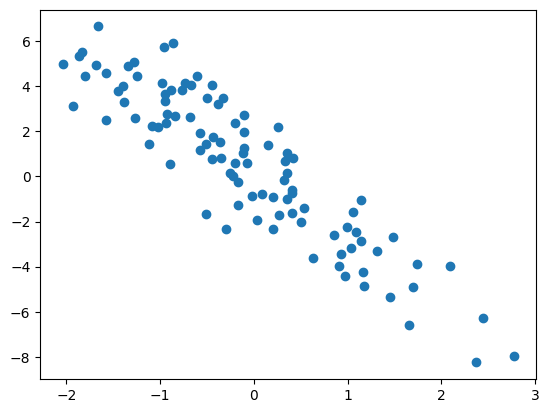

In [114]:
plt.scatter(t, X_bk)
plt.show()

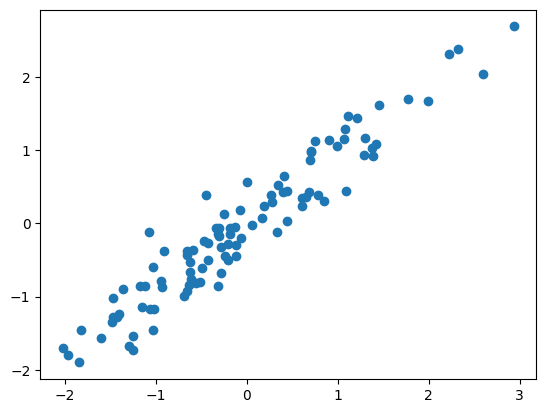

In [115]:
plt.scatter(r, mdl_latent.predict(t))
plt.show()

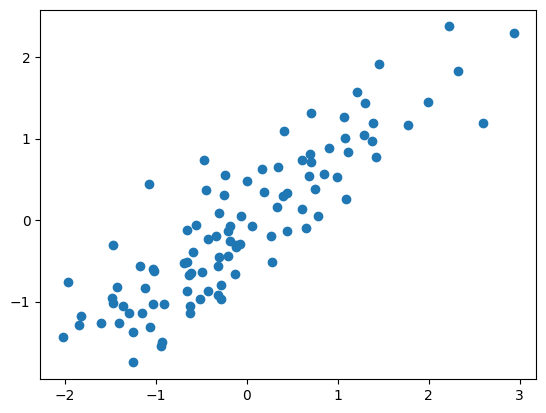

In [116]:
plt.scatter(r, mdl_pca.predict(X_bk))
plt.show()

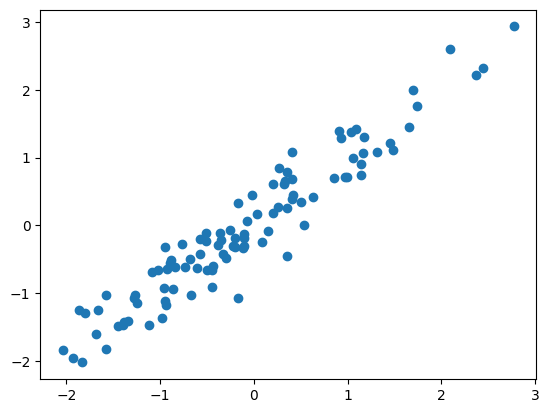

In [118]:
plt.scatter(t, r)
plt.show()

In [88]:
r.shape

(100, 100)